# Diffusion Models for Image Generation

This colab notebook is a demonstration of a denoising diffusion model trained on CelebA faces.
The mathematical details are explained in the `README.md`; here, the focus is on running the model and visualizing the result.

**1. Load data**: Prepare the CelebA image dataset.  
**2. Train**: Train a U-Net to predict added noise.  
**3. Generate**: Reverse noise into generated face images.

In [1]:
# Cloning the repository and installing the uninstalled dependencies:

!rm -rf diffusion
!git clone https://github.com/jpmansour-ai-dev/Diffusion.git diffusion
%cd diffusion

%pip install -q -e .

Cloning into 'diffusion'...
remote: Enumerating objects: 282, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 282 (delta 55), reused 33 (delta 27), pack-reused 198 (from 1)
Receiving objects: 100% (282/282), 2.04 MiB | 33.22 MiB/s, done.
Resolving deltas: 100% (125/125), done.
/content/diffusion
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for diffusion (pyproject.toml) ... done


## Loading Dataset

In [2]:
# Load the image datasets:

import os, warnings
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore", category=UserWarning)

from datasets.utils.logging import disable_progress_bar, set_verbosity_error
from data.data_loader import get_celeba_loader

disable_progress_bar()
set_verbosity_error()

print("Loading CelebA dataset...")
loader = get_celeba_loader()
print("Done.")

Loading CelebA dataset...


Done.


## Training

In [3]:
# Train the model:

import torch
from model.unet import UNet
from training.training import fit

torch.manual_seed(0)
model = UNet()

os.makedirs("checkpoints", exist_ok=True)

losses = fit(model, loader, epochs=35, model_path="checkpoints/unet.pt")

UNet learnable parameters count: 17,234,243
Epoch 1/35 - loss: 0.02574
Epoch 2/35 - loss: 0.01954
Epoch 3/35 - loss: 0.01878
Epoch 4/35 - loss: 0.01865
Epoch 5/35 - loss: 0.01848
Epoch 6/35 - loss: 0.01801
Epoch 7/35 - loss: 0.01800
Epoch 8/35 - loss: 0.01802
Epoch 9/35 - loss: 0.01791
Epoch 10/35 - loss: 0.01767
Epoch 11/35 - loss: 0.01788
Epoch 12/35 - loss: 0.01775
Epoch 13/35 - loss: 0.01764
Epoch 14/35 - loss: 0.01781
Epoch 15/35 - loss: 0.01776
Epoch 16/35 - loss: 0.01776
Epoch 17/35 - loss: 0.01741
Epoch 18/35 - loss: 0.01745
Epoch 19/35 - loss: 0.01750
Epoch 20/35 - loss: 0.01767
Epoch 21/35 - loss: 0.01743
Epoch 22/35 - loss: 0.01766
Epoch 23/35 - loss: 0.01739
Epoch 24/35 - loss: 0.01747
Epoch 25/35 - loss: 0.01748
Epoch 26/35 - loss: 0.01731
Epoch 27/35 - loss: 0.01736
Epoch 28/35 - loss: 0.01728
Epoch 29/35 - loss: 0.01732
Epoch 30/35 - loss: 0.01750
Epoch 31/35 - loss: 0.01735
Epoch 32/35 - loss: 0.01737
Epoch 33/35 - loss: 0.01742
Epoch 34/35 - loss: 0.01727
Epoch 35/35 -

## Image Generation


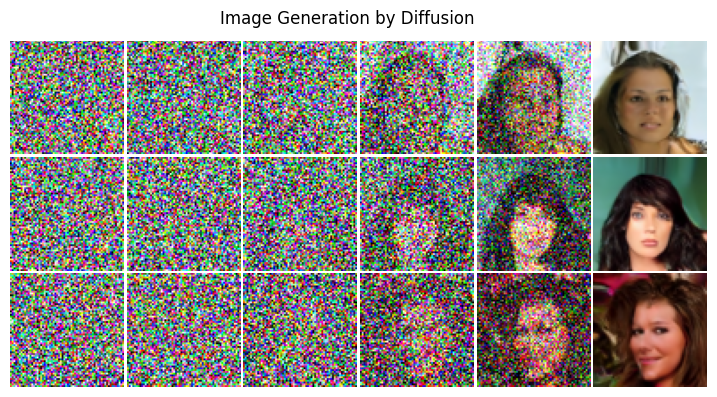

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from diffusion.forward import T
from diffusion.reverse import reverse_step


def to_img(x: torch.Tensor) -> np.ndarray:
    return ((x.clamp(-1, 1) + 1) / 2).permute(1, 2, 0).cpu().numpy()


timesteps = [1000, 800, 600, 400, 200, 0]
x = torch.randn(3, 3, 64, 64, device=next(model.parameters()).device)
snapshots = {}

with torch.no_grad():
    for t in reversed(range(T)):
        if t + 1 in set(timesteps):
            snapshots[t + 1] = x.clone()
        x = reverse_step(model, x, t)
snapshots[0] = x

fig, axes = plt.subplots(3, len(timesteps), figsize=(len(timesteps) * 1.5, 3 * 1.5))
for j, t in enumerate(timesteps):
    for i in range(3):
        axes[i, j].imshow(to_img(snapshots[t][i]))
        axes[i, j].axis("off")

fig.suptitle("Image Generation by Diffusion", y=0.95)
plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

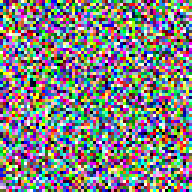

In [86]:
import io
from IPython.display import display, Image
from PIL import Image as PILImage
from torchvision.utils import make_grid


def batch_to_image(x: torch.Tensor, nrow: int = 1, scale: int = 1) -> PILImage.Image:
    grid = make_grid((x.clamp(-1, 1) + 1) / 2, nrow=nrow)
    arr = (grid.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    img = PILImage.fromarray(arr)
    if scale > 1:
        img = img.resize((img.width * scale, img.height * scale), PILImage.NEAREST)
    return img


@torch.no_grad()
def denoising_gif(model, shape=(1, 3, 64, 64), capture_every=25, scale=3):
    x = torch.randn(shape, device=next(model.parameters()).device)
    frames = []

    for t in reversed(range(T)):
        if t % capture_every == 0:
            frames.append(batch_to_image(x, nrow=shape[0], scale=scale))
        x = reverse_step(model, x, t)

    final_frame = batch_to_image(x, nrow=shape[0], scale=scale)
    frames.extend([final_frame] + [final_frame.copy() for _ in range(8)])

    buffer = io.BytesIO()
    frames[0].save(
        buffer,
        format="GIF",
        save_all=True,
        append_images=frames[1:],
        duration=40,
        loop=0,
    )
    return buffer.getvalue()


gif_bytes = denoising_gif(model)
display(Image(data=gif_bytes))